Carregando os arquivos CSV...


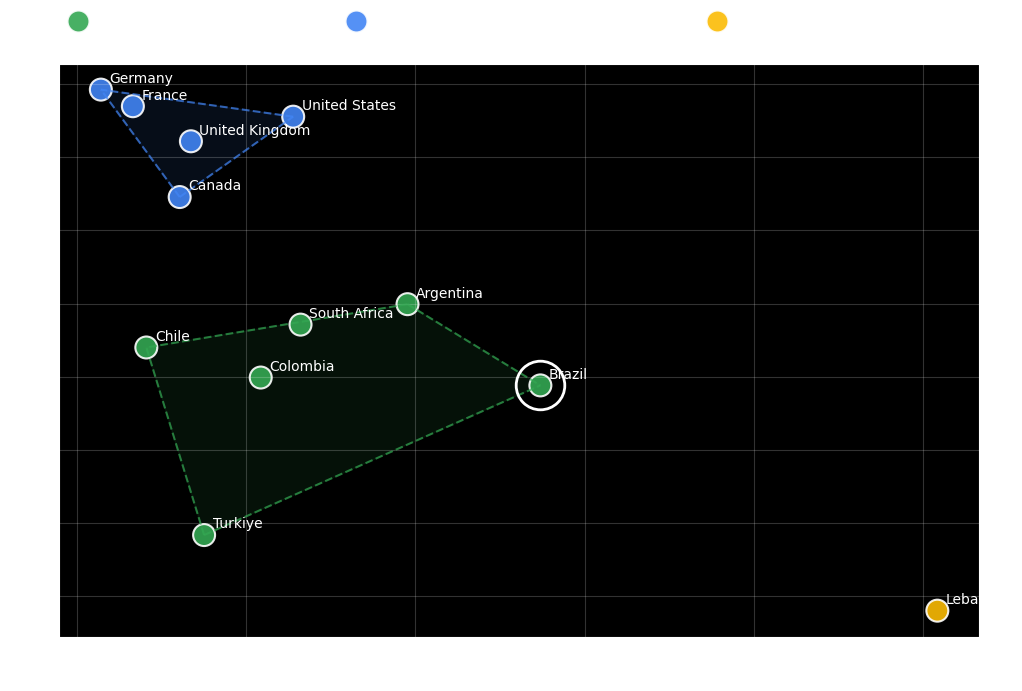

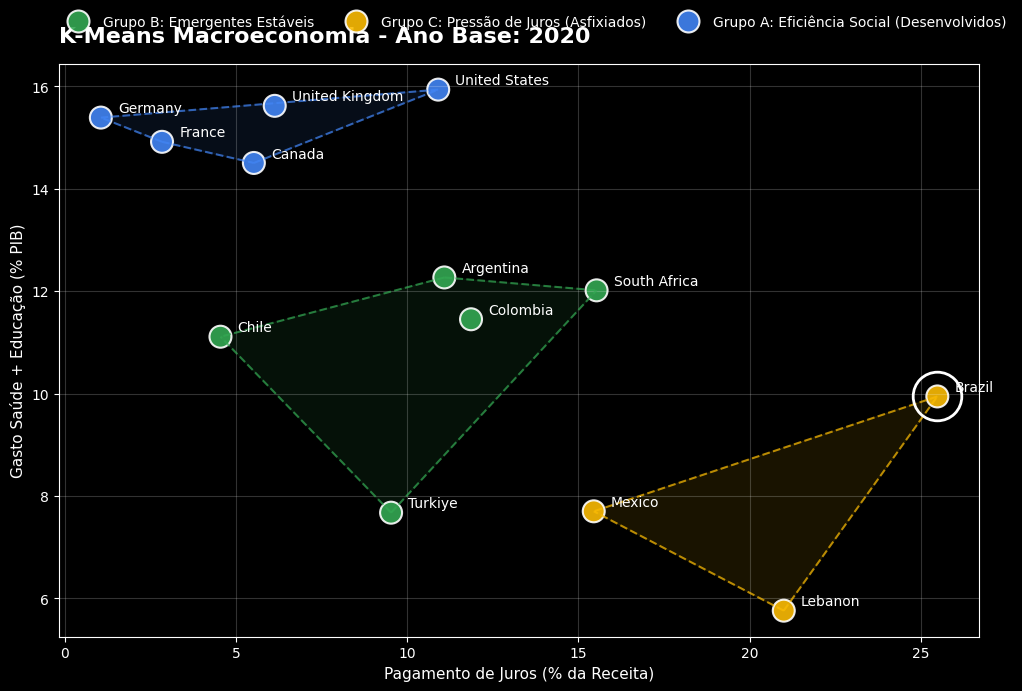

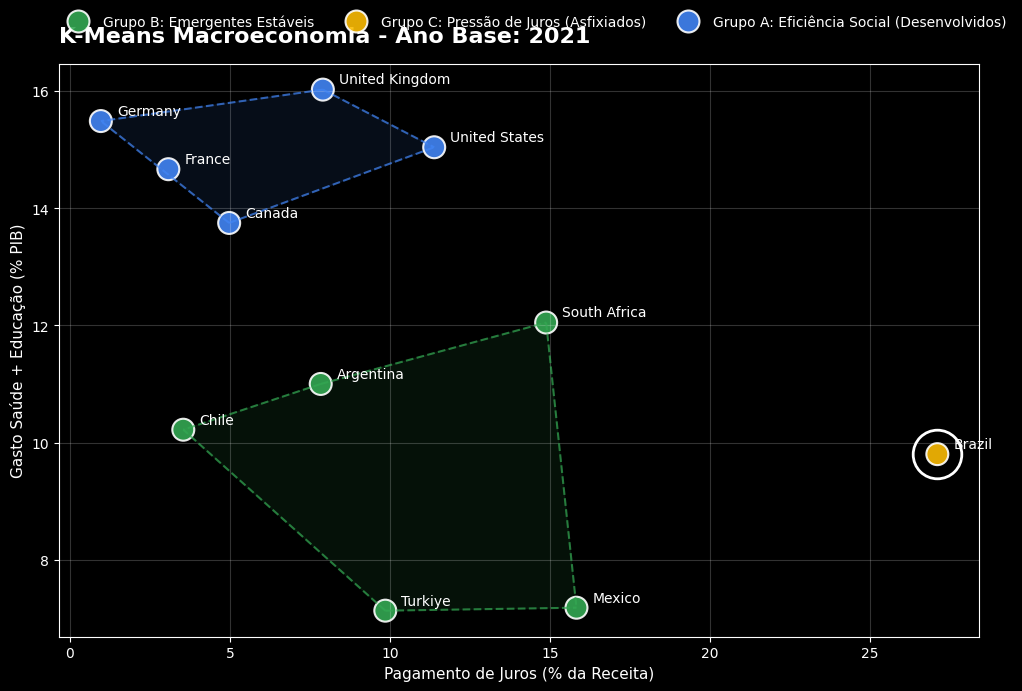

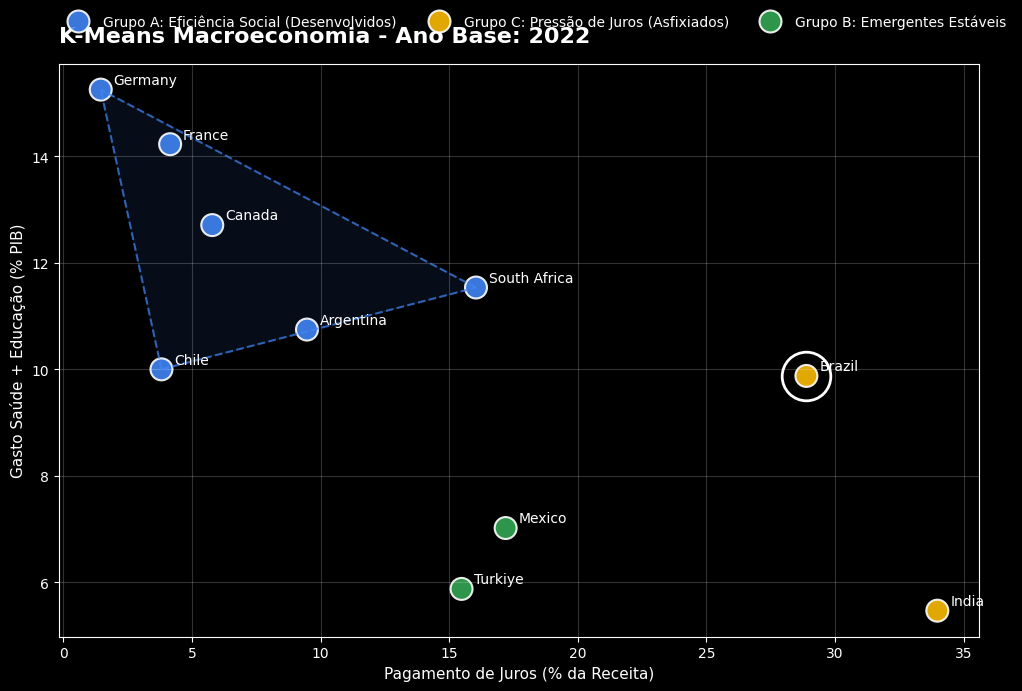


⚠️ Pulando 2023: O Banco Mundial ainda não publicou dados suficientes para este ano.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull

# 1. CARREGAMENTO DOS DADOS
print("Carregando os arquivos CSV...")
df_edu = pd.read_csv('API_SE.XPD.TOTL.GD.ZS_DS2_en_csv_v2_115540.csv', skiprows=4)
df_sau = pd.read_csv('API_SH.XPD.GHED.GD.ZS_DS2_en_csv_v2_115647.csv', skiprows=4)
df_jur = pd.read_csv('API_GC.XPN.INTP.RV.ZS_DS2_en_csv_v2_10000.csv', skiprows=4)

# 2. DEFINIÇÃO DA ANÁLISE
anos_analise = ['2019', '2020', '2021', '2022', '2023']

# 15 países equilibrados para o gráfico não ficar poluído
paises_destaque = [
    'DEU', 'GBR', 'USA', 'FRA', 'CAN', # Historicamente Desenvolvidos
    'IND', 'MEX', 'CHL', 'COL', 'TUR', # Historicamente Emergentes
    'BRA', 'ARG', 'EGY', 'ZAF', 'LBN'  # Historicamente Asfixiados
]

# 3. LOOP DE GERAÇÃO ANO A ANO
for ano in anos_analise:
    
    # Extração dos dados exatos do ano corrente
    edu = df_edu[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Educacao_PIB'})
    sau = df_sau[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Saude_PIB'})
    jur = df_jur[['Country Code', 'Country Name', ano]].rename(columns={ano: 'Juros_Receita'})
    
    # Merge das tabelas
    df_ano = edu.merge(sau, on=['Country Code', 'Country Name'])
    df_ano = df_ano.merge(jur, on=['Country Code', 'Country Name'])
    df_ano['Gasto_Social'] = df_ano['Educacao_PIB'] + df_ano['Saude_PIB']
    
    # Filtro de países e remoção de dados nulos daquele ano
    df_plot = df_ano[df_ano['Country Code'].isin(paises_destaque)].copy()
    df_plot = df_plot.dropna()
    
    # Trava de segurança: Se o Banco Mundial ainda não tiver dados de pelo menos 6 países no ano, ele pula
    if len(df_plot) < 6:
        print(f"\n⚠️ Pulando {ano}: O Banco Mundial ainda não publicou dados suficientes para este ano.")
        continue

    # 4. PADRONIZAÇÃO E K-MEANS PARA O ANO ATUAL
    X = df_plot[['Juros_Receita', 'Gasto_Social']]
    scaler = StandardScaler()
    X_padronizado = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    df_plot['Cluster_ID'] = kmeans.fit_predict(X_padronizado)

    # Identificando quem é quem matematicamente (dinâmico)
    centroides = df_plot.groupby('Cluster_ID')[['Juros_Receita', 'Gasto_Social']].mean()
    id_desenvolvidos = centroides['Gasto_Social'].idxmax()
    id_asfixiados = centroides['Juros_Receita'].idxmax()
    id_emergentes = [i for i in range(3) if i not in [id_desenvolvidos, id_asfixiados]][0]

    mapa_nomes = {
        id_desenvolvidos: 'Grupo A: Eficiência Social (Desenvolvidos)',
        id_emergentes: 'Grupo B: Emergentes Estáveis',
        id_asfixiados: 'Grupo C: Pressão de Juros (Asfixiados)'
    }
    df_plot['Nome_Cluster'] = df_plot['Cluster_ID'].map(mapa_nomes)

    # 5. VISUALIZAÇÃO
    plt.figure(figsize=(11, 7)) # Tamanho otimizado para o Jupyter
    plt.style.use('dark_background')
    cores = {
        'Grupo A: Eficiência Social (Desenvolvidos)': '#4285F4', 
        'Grupo B: Emergentes Estáveis': '#34A853', 
        'Grupo C: Pressão de Juros (Asfixiados)': '#FBBC05'
    }

    # Desenhando os polígonos (Convex Hull)
    for nome, grupo in df_plot.groupby('Nome_Cluster'):
        pontos = grupo[['Juros_Receita', 'Gasto_Social']].values
        if len(pontos) >= 3:
            hull = ConvexHull(pontos)
            for simplex in hull.simplices:
                plt.plot(pontos[simplex, 0], pontos[simplex, 1], color=cores[nome], linestyle='--', linewidth=1.5, alpha=0.7)
            plt.fill(pontos[hull.vertices, 0], pontos[hull.vertices, 1], color=cores[nome], alpha=0.1)

    # Plotando os pontos
    sns.scatterplot(
        data=df_plot, x='Juros_Receita', y='Gasto_Social', 
        hue='Nome_Cluster', palette=cores, s=250, alpha=0.9, edgecolor='white', linewidth=1.5
    )

    # Nomes dos países
    for i in range(df_plot.shape[0]):
        plt.annotate(
            df_plot['Country Name'].iloc[i], 
            (df_plot['Juros_Receita'].iloc[i] + 0.5, df_plot['Gasto_Social'].iloc[i] + 0.1),
            fontsize=10, color='white'
        )

    # Circulando o Brasil (Xeque-Mate)
    brasil_data = df_plot[df_plot['Country Code'] == 'BRA']
    if not brasil_data.empty:
        plt.plot(brasil_data['Juros_Receita'].values[0], brasil_data['Gasto_Social'].values[0], 
                 'o', ms=35, mec='white', mfc='none', mew=2)

    plt.title(f'K-Means Macroeconomia - Ano Base: {ano}', fontsize=16, fontweight='bold', pad=15, loc='left')
    plt.xlabel('Pagamento de Juros (% da Receita)', fontsize=11)
    plt.ylabel('Gasto Saúde + Educação (% PIB)', fontsize=11)
    plt.legend(bbox_to_anchor=(0, 1.05), loc='lower left', borderaxespad=0, ncol=3, frameon=False)
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()